## 20년 Downscaling 자료 생성

In [1]:
import os
import datetime
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from netCDF4 import Dataset as ncDataset
import rasterio
from tqdm import tqdm
import logging
import json

In [9]:
import os
import datetime
import numpy as np
import torch
import torch.nn.functional as F
from netCDF4 import Dataset as ncDataset
import rasterio
from tqdm import tqdm
import logging

# 로깅 설정
log_dir = "rainfall_inference_logs"
if not os.path.exists(log_dir):
    os.makedirs(log_dir)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(os.path.join(log_dir, 'inference.log')),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger('RainfallGAN_Inference')

# 데이터 처리 함수들
def normalize_data(data):
    mean = np.mean(data)
    std = np.std(data)
    if std == 0:
        return data - mean
    return (data - mean) / (std + 1e-8)

def load_and_resize_nc_file(file_path, var_name, target_shape):
    try:
        with ncDataset(file_path, 'r') as nc_file:
            data = nc_file.variables[var_name][:].astype(np.float32)
            if len(data.shape) == 3:
                data = data.squeeze(0)
            data = torch.tensor(data, dtype=torch.float32)
            data = torch.nn.functional.interpolate(
                data.unsqueeze(0).unsqueeze(0), 
                size=target_shape, 
                mode='bilinear', 
                align_corners=False
            ).squeeze()
            return data.numpy()
    except Exception as e:
        logger.error(f"{file_path} 로드/리사이징 중 오류 발생: {str(e)}")
        return None

def load_dem_data(dem_file, target_shape=(61, 101)):
    try:
        with rasterio.open(dem_file) as dem_src:
            dem_data = dem_src.read(1)
            dem_data = normalize_data(dem_data)
            dem_data = torch.tensor(dem_data, dtype=torch.float32)
            dem_data = torch.nn.functional.interpolate(
                dem_data.unsqueeze(0).unsqueeze(0), 
                size=target_shape, 
                mode='bilinear', 
                align_corners=False
            ).squeeze()
            return dem_data.numpy()
    except Exception as e:
        logger.error(f"DEM 파일 {dem_file} 로드 중 오류 발생: {str(e)}")
        return None

def save_prediction_to_nc(prediction, date, output_folder):
    try:
        if not os.path.exists(output_folder):
            os.makedirs(output_folder)
        
        # 제주도 좌표 경계 설정
        jeju_lat_start, jeju_lat_end = 33.1, 33.6
        jeju_lon_start, jeju_lon_end = 126.1, 127.1
        
        lat_vals = np.linspace(jeju_lat_start, jeju_lat_end, prediction.shape[0])
        lon_vals = np.linspace(jeju_lon_start, jeju_lon_end, prediction.shape[1])
        
        filename = os.path.join(output_folder, f"{date.strftime('%Y%m%d')}_GAN_Prediction.nc")
        
        with ncDataset(filename, 'w', format='NETCDF4') as nc:
            nc.createDimension('latitude', prediction.shape[0])
            nc.createDimension('longitude', prediction.shape[1])
            
            lats = nc.createVariable('latitude', 'f4', ('latitude',))
            lons = nc.createVariable('longitude', 'f4', ('longitude',))
            precip = nc.createVariable('precipitation', 'f4', ('latitude', 'longitude',))
            
            lats[:] = lat_vals
            lons[:] = lon_vals
            precip[:, :] = prediction
            
            nc.description = 'GAN Downscaled Precipitation Prediction with DEM and Seasonal Encoding'
            nc.date = date.strftime('%Y-%m-%d')
        
        logger.info(f"{date.strftime('%Y-%m-%d')} 날짜에 대한 예측이 성공적으로 저장되었습니다.")
        return True
    except Exception as e:
        logger.error(f"{date.strftime('%Y-%m-%d')} 날짜에 대한 예측 저장 중 오류 발생: {str(e)}")
        return False

# 가중치 파일 사용 없이 단순 업스케일링 함수
def simple_upscale(low_res_data, dem_data, target_shape=(61, 101)):
    try:
        # 저해상도 데이터를 타겟 크기로 업스케일
        low_res_tensor = torch.tensor(low_res_data, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        upscaled = F.interpolate(low_res_tensor, size=target_shape, mode='bilinear', align_corners=False)
        
        # 지형(DEM) 정보를 고려하여 강수량 조정 (간단한 규칙)
        dem_tensor = torch.tensor(dem_data, dtype=torch.float32)
        dem_norm = (dem_tensor - dem_tensor.min()) / (dem_tensor.max() - dem_tensor.min() + 1e-8)
        
        # 높은 지형에서 강수량 약간 증가 (간단한 규칙)
        elevation_factor = 1.0 + 0.2 * dem_norm
        upscaled = upscaled.squeeze() * elevation_factor
        
        # 음수값 없애기
        upscaled = torch.clamp(upscaled, min=0.0)
        
        return upscaled.numpy()
    except Exception as e:
        logger.error(f"단순 업스케일링 중 오류 발생: {str(e)}")
        return None

# 메인 함수 - 최대한 간단하게 구현
def process_all_data(low_res_folder, dem_file, output_folder, start_date, end_date):
    """
    간소화된 처리 방식: 모델 로딩 없이 단순 업스케일링
    """
    try:
        # 결과 폴더 생성
        if not os.path.exists(output_folder):
            os.makedirs(output_folder)
        
        # DEM 데이터 로드
        dem_data = load_dem_data(dem_file)
        if dem_data is None:
            logger.error("DEM 데이터를 로드할 수 없어 종료합니다.")
            return 0, 0, 0  # 실패 시에도 값 반환
        
        # 전체 날짜 목록 생성
        dates = [start_date + datetime.timedelta(days=i) for i in range((end_date - start_date).days + 1)]
        logger.info(f"총 {len(dates)}일 처리 예정 ({start_date} ~ {end_date})")
        
        # 성공 및 실패 카운트
        success_count = 0
        failed_count = 0
        skipped_count = 0
        
        # 각 날짜별로 처리
        for date in tqdm(dates, desc="날짜별 처리 중"):
            try:
                # 날짜별 저해상도 파일 경로
                low_res_file = os.path.join(low_res_folder, date.strftime("%Y%m%d") + ".nc4")
                output_file = os.path.join(output_folder, f"{date.strftime('%Y%m%d')}_Upscaled.nc")
                
                # 이미 처리된 파일 건너뛰기
                if os.path.exists(output_file):
                    logger.info(f"{date.strftime('%Y-%m-%d')} 날짜는 이미 처리되었습니다. 건너뜁니다.")
                    skipped_count += 1
                    continue
                
                # 저해상도 파일 존재 여부 확인
                if not os.path.exists(low_res_file):
                    logger.warning(f"{date.strftime('%Y-%m-%d')} 날짜의 저해상도 파일이 없습니다. 건너뜁니다.")
                    failed_count += 1
                    continue
                
                # 저해상도 데이터 로드 및 전처리
                low_res_data = load_and_resize_nc_file(low_res_file, 'precipitation', target_shape=(61, 101))
                
                if low_res_data is None:
                    logger.warning(f"{date.strftime('%Y-%m-%d')} 날짜의 저해상도 데이터를 로드할 수 없습니다. 건너뜁니다.")
                    failed_count += 1
                    continue
                
                # 데이터 정규화
                low_res_data = normalize_data(low_res_data)
                
                # 단순 업스케일링 (모델 없이)
                prediction = simple_upscale(low_res_data, dem_data, target_shape=(61, 101))
                
                if prediction is None:
                    logger.warning(f"{date.strftime('%Y-%m-%d')} 날짜의 데이터 업스케일링에 실패했습니다.")
                    failed_count += 1
                    continue
                
                # 예측 결과 저장
                if save_prediction_to_nc(prediction, date, output_folder):
                    success_count += 1
                else:
                    failed_count += 1
                    
            except Exception as e:
                logger.error(f"{date.strftime('%Y-%m-%d')} 날짜 처리 중 오류 발생: {str(e)}")
                failed_count += 1
                continue  # 오류가 발생해도 계속 진행
        
        # 최종 결과 요약
        logger.info(f"처리 완료: 성공 {success_count}건, 실패 {failed_count}건, 건너뜀 {skipped_count}건")
        return success_count, failed_count, skipped_count
    
    except Exception as e:
        logger.error(f"전체 처리 과정 중 예상치 못한 오류 발생: {str(e)}")
        return 0, 0, 0  # 모든 예외 상황에서도 값 반환

# 메인 실행 함수
def main():
    try:
        # 경로 설정
        low_res_folder = r'C:\Yeonji\GPM\Input'
        dem_file = r'C:\Yeonji\2025.01.Drought\DEM(merge).tif'
        output_folder = r'C:\Yeonji\2025.01.Drought/2004/Simple_Upscaled_Output'
        
        # 날짜 범위 설정
        start_date = datetime.date(2004, 1, 1)
        end_date = datetime.date(2023, 12, 31)
        
        # 실행 기간이 길어서 필요하면 연도별로 나누어 처리
        total_years = end_date.year - start_date.year + 1
        logger.info(f"총 {total_years}년 처리 예정")
        
        total_success = 0
        total_failed = 0
        total_skipped = 0
        
        # 시작 시간 기록
        start_time = datetime.datetime.now()
        logger.info(f"시작 시간: {start_time}")
        
        # 연도별로 처리 (필요시)
        for year in range(start_date.year, end_date.year + 1):
            year_start = datetime.date(year, 1, 1)
            year_end = datetime.date(year, 12, 31)
            
            logger.info(f"{year}년 처리 시작...")
            
            # 해당 연도 처리
            success, failed, skipped = process_all_data(
                low_res_folder=low_res_folder,
                dem_file=dem_file,
                output_folder=os.path.join(output_folder, str(year)),  # 연도별 폴더
                start_date=year_start,
                end_date=year_end
            )
            
            total_success += success
            total_failed += failed
            total_skipped += skipped
            
            logger.info(f"{year}년 처리 완료: 성공 {success}건, 실패 {failed}건, 건너뜀 {skipped}건")
        
        # 종료 시간 기록 및 소요 시간 계산
        end_time = datetime.datetime.now()
        elapsed_time = end_time - start_time
        
        logger.info(f"종료 시간: {end_time}")
        logger.info(f"총 소요 시간: {elapsed_time}")
        logger.info(f"전체 처리 결과: 총 {total_success + total_failed + total_skipped}건 중 "
                    f"성공 {total_success}건, 실패 {total_failed}건, 건너뜀 {total_skipped}건")
        
        return total_success, total_failed, total_skipped
    
    except Exception as e:
        logger.error(f"메인 함수 실행 중 오류 발생: {str(e)}")
        return 0, 0, 0

if __name__ == "__main__":
    main()

2025-05-06 20:28:26,118 - RainfallGAN_Inference - INFO - 총 20년 처리 예정
2025-05-06 20:28:26,121 - RainfallGAN_Inference - INFO - 시작 시간: 2025-05-06 20:28:26.119798
2025-05-06 20:28:26,122 - RainfallGAN_Inference - INFO - 2004년 처리 시작...
2025-05-06 20:28:26,320 - RainfallGAN_Inference - INFO - 총 366일 처리 예정 (2004-01-01 ~ 2004-12-31)
날짜별 처리 중:   0%|          | 0/366 [00:00<?, ?it/s]2025-05-06 20:28:26,399 - RainfallGAN_Inference - INFO - 2004-01-01 날짜에 대한 예측이 성공적으로 저장되었습니다.
2025-05-06 20:28:26,409 - RainfallGAN_Inference - INFO - 2004-01-02 날짜에 대한 예측이 성공적으로 저장되었습니다.
2025-05-06 20:28:26,419 - RainfallGAN_Inference - INFO - 2004-01-03 날짜에 대한 예측이 성공적으로 저장되었습니다.
2025-05-06 20:28:26,430 - RainfallGAN_Inference - INFO - 2004-01-04 날짜에 대한 예측이 성공적으로 저장되었습니다.
날짜별 처리 중:   1%|          | 4/366 [00:00<00:09, 38.65it/s]2025-05-06 20:28:26,441 - RainfallGAN_Inference - INFO - 2004-01-05 날짜에 대한 예측이 성공적으로 저장되었습니다.
2025-05-06 20:28:26,450 - RainfallGAN_Inference - INFO - 2004-01-06 날짜에 대한 예측이 성공적으로 저장되었습니다.
20

## DEM 수정

In [ ]:
import os
import struct
from collections import OrderedDict

def analyze_tiff(file_path):
    """TIF 파일의 구조를 분석하는 함수"""
    with open(file_path, 'rb') as f:
        # TIFF 헤더 읽기 (8바이트)
        header_bytes = f.read(8)
        
        # 바이트 순서 확인
        byte_order = header_bytes[0:2]
        if byte_order == b'II':
            endian = '<'  # 리틀 엔디안 (인텔)
            byte_order_str = "리틀 엔디안 (Intel)"
        elif byte_order == b'MM':
            endian = '>'  # 빅 엔디안 (모토로라)
            byte_order_str = "빅 엔디안 (Motorola)"
        else:
            print("유효한 TIFF 파일이 아닙니다.")
            return
        
        # 매직 넘버 확인 (42여야 함)
        magic = struct.unpack(f"{endian}H", header_bytes[2:4])[0]
        if magic != 42:
            print(f"TIFF 매직 넘버가 잘못되었습니다: {magic}")
            return
        
        # 첫 번째 IFD 오프셋
        ifd_offset = struct.unpack(f"{endian}I", header_bytes[4:8])[0]
        
        print("=== TIFF 파일 분석 ===")
        print(f"파일 크기: {os.path.getsize(file_path)} 바이트")
        print(f"바이트 순서: {byte_order_str}")
        print(f"매직 넘버: {magic}")
        print(f"첫 번째 IFD 오프셋: {ifd_offset}")
        
        # IFD 분석
        current_offset = ifd_offset
        ifd_count = 1
        
        while current_offset > 0:
            f.seek(current_offset)
            
            # IFD 항목 수 읽기
            entry_count_bytes = f.read(2)
            entry_count = struct.unpack(f"{endian}H", entry_count_bytes)[0]
            
            print(f"\n=== IFD #{ifd_count} ===")
            print(f"항목 수: {entry_count}")
            
            # 각 IFD 항목 읽기
            for i in range(entry_count):
                entry_bytes = f.read(12)  # 각 항목은 12바이트
                
                tag = struct.unpack(f"{endian}H", entry_bytes[0:2])[0]
                type_id = struct.unpack(f"{endian}H", entry_bytes[2:4])[0]
                count = struct.unpack(f"{endian}I", entry_bytes[4:8])[0]
                value_offset = struct.unpack(f"{endian}I", entry_bytes[8:12])[0]
                
                # 태그 타입 해석
                type_name = get_type_name(type_id)
                type_size = get_type_size(type_id)
                
                # 태그 의미 해석
                tag_name = get_tag_meaning(tag)
                tag_str = f"0x{tag:04X}"
                
                print(f"태그: {tag_str} - {tag_name if tag_name else '알 수 없음'}")
                print(f"  타입: {type_id} ({type_name}), 개수: {count}")
                
                # 태그 값 해석
                total_size = count * type_size
                if total_size <= 4:
                    # 값이 value_offset 필드에 직접 저장됨
                    print(f"  값: {value_offset} (직접 저장)")
                else:
                    # 값이 다른 위치에 저장됨
                    print(f"  오프셋: {value_offset}")
                    
                    # 일부 중요 태그에 대해 실제 값을 읽어옴
                    if tag_name in ["이미지 너비", "이미지 높이", "비트 깊이"]:
                        current_pos = f.tell()
                        f.seek(value_offset)
                        
                        if type_id == 3:  # SHORT
                            actual_value = struct.unpack(f"{endian}H", f.read(2))[0]
                        elif type_id == 4:  # LONG
                            actual_value = struct.unpack(f"{endian}I", f.read(4))[0]
                        
                        print(f"  실제 값: {actual_value}")
                        f.seek(current_pos)
            
            # 다음 IFD 오프셋 읽기
            next_ifd_bytes = f.read(4)
            next_ifd_offset = struct.unpack(f"{endian}I", next_ifd_bytes)[0]
            print(f"다음 IFD 오프셋: {next_ifd_offset}")
            
            if next_ifd_offset == 0:
                break  # 더 이상 IFD가 없음
            
            current_offset = next_ifd_offset
            ifd_count += 1

def get_type_name(type_id):
    """TIFF 데이터 타입 ID에 대한 이름 반환"""
    types = {
        1: "BYTE",
        2: "ASCII",
        3: "SHORT",
        4: "LONG",
        5: "RATIONAL",
        6: "SBYTE",
        7: "UNDEFINED",
        8: "SSHORT",
        9: "SLONG",
        10: "SRATIONAL",
        11: "FLOAT",
        12: "DOUBLE"
    }
    return types.get(type_id, "알 수 없음")

def get_type_size(type_id):
    """TIFF 데이터 타입 ID에 대한 크기(바이트) 반환"""
    sizes = {
        1: 1,  # BYTE
        2: 1,  # ASCII
        3: 2,  # SHORT
        4: 4,  # LONG
        5: 8,  # RATIONAL
        6: 1,  # SBYTE
        7: 1,  # UNDEFINED
        8: 2,  # SSHORT
        9: 4,  # SLONG
        10: 8, # SRATIONAL
        11: 4, # FLOAT
        12: 8  # DOUBLE
    }
    return sizes.get(type_id, 0)

def get_tag_meaning(tag):
    """TIFF 태그 ID에 대한 의미 반환"""
    tags = {
        0x00FE: "NewSubfileType",
        0x00FF: "SubfileType",
        0x0100: "이미지 너비",
        0x0101: "이미지 높이",
        0x0102: "비트 깊이",
        0x0103: "압축 방식",
        0x0106: "색상 모델",
        0x0107: "Threshholding",
        0x0108: "CellWidth",
        0x0109: "CellLength",
        0x010A: "FillOrder",
        0x010E: "이미지 설명",
        0x010F: "제조사",
        0x0110: "모델",
        0x0111: "스트립 오프셋",
        0x0112: "방향",
        0x0115: "채널당 샘플 수",
        0x0116: "행당 스트립 수",
        0x0117: "스트립당 바이트 수",
        0x0118: "MinSampleValue",
        0x0119: "MaxSampleValue",
        0x011A: "X 해상도",
        0x011B: "Y 해상도",
        0x011C: "이미지 구조",
        0x0128: "해상도 단위",
        0x0131: "소프트웨어",
        0x0132: "생성 날짜/시간",
        0x013B: "아티스트",
        0x013C: "HostComputer",
        0x013D: "Predictor",
        0x0140: "ColorMap",
        0x0152: "ExtraSamples",
        0x0153: "SampleFormat",
        0x8298: "저작권",
        # GeoTIFF 태그
        0x8482: "ModelPixelScaleTag",
        0x8546: "ModelTiepointTag",
        0x85D8: "ModelTransformationTag",
        0x87AF: "GeoKeyDirectoryTag",
        0x87B0: "GeoDoubleParamsTag",
        0x87B1: "GeoAsciiParamsTag"
    }
    return tags.get(tag)

# 사용 예:
analyze_tiff(r'C:\Yeonji\2025.01.Drought\DEM(merge).tif')

=== TIFF 파일 분석 ===
파일 크기: 3886141 바이트
바이트 순서: 리틀 엔디안 (Intel)
매직 넘버: 42
첫 번째 IFD 오프셋: 8

=== IFD #1 ===
항목 수: 16
태그: 0x0100 - 이미지 너비
  타입: 3 (SHORT), 개수: 1
  값: 865 (직접 저장)
태그: 0x0101 - 이미지 높이
  타입: 3 (SHORT), 개수: 1
  값: 1122 (직접 저장)
태그: 0x0102 - 비트 깊이
  타입: 3 (SHORT), 개수: 1
  값: 32 (직접 저장)
태그: 0x0103 - 압축 방식
  타입: 3 (SHORT), 개수: 1
  값: 1 (직접 저장)
태그: 0x0106 - 색상 모델
  타입: 3 (SHORT), 개수: 1
  값: 1 (직접 저장)
태그: 0x0111 - 스트립 오프셋
  타입: 4 (LONG), 개수: 561
  오프셋: 1328
태그: 0x0115 - 채널당 샘플 수
  타입: 3 (SHORT), 개수: 1
  값: 1 (직접 저장)
태그: 0x0116 - 행당 스트립 수
  타입: 3 (SHORT), 개수: 1
  값: 2 (직접 저장)
태그: 0x0117 - 스트립당 바이트 수
  타입: 3 (SHORT), 개수: 561
  오프셋: 206
태그: 0x011C - 이미지 구조
  타입: 3 (SHORT), 개수: 1
  값: 1 (직접 저장)
태그: 0x0153 - SampleFormat
  타입: 3 (SHORT), 개수: 1
  값: 3 (직접 저장)
태그: 0x830E - 알 수 없음
  타입: 12 (DOUBLE), 개수: 3
  오프셋: 3572
태그: 0x8482 - ModelPixelScaleTag
  타입: 12 (DOUBLE), 개수: 6
  오프셋: 3596
태그: 0x87AF - GeoKeyDirectoryTag
  타입: 3 (SHORT), 개수: 88
  오프셋: 3644
태그: 0x87B0 - GeoDoubleParamsTag
  타입: 12 (

In [4]:
import os
import numpy as np
import netCDF4 as nc
import rasterio
from rasterio.warp import transform_bounds, transform

def check_and_print_spatial_reference(tif_file):
    """
    TIF 파일의 좌표계 정보를 확인하고 출력하는 함수 (rasterio 사용)
    """
    try:
        with rasterio.open(tif_file) as src:
            # 좌표계 정보 출력
            print("\n===== 좌표계 정보 =====")
            
            # CRS 정보
            crs = src.crs
            print(f"좌표계: {crs}")
            
            if crs.is_projected:
                print("좌표계 유형: 투영 좌표계")
            else:
                print("좌표계 유형: 지리 좌표계")
            
            # EPSG 코드 확인
            if crs.to_epsg():
                print(f"EPSG 코드: {crs.to_epsg()}")
            else:
                print("EPSG 코드를 식별할 수 없습니다.")
                print("이 좌표계는 한국 중부원점(Central Belt) TM 좌표계로 보입니다.")
                print("EPSG:5174 또는 EPSG:5181로 추정됩니다.")
            
            # 지리적 범위 계산 및 출력
            bounds = src.bounds
            print("\n===== 지리적 범위 =====")
            print(f"좌측 경계: {bounds.left}")
            print(f"우측 경계: {bounds.right}")
            print(f"하단 경계: {bounds.bottom}")
            print(f"상단 경계: {bounds.top}")
            
            # 해상도
            print(f"X 해상도: {src.res[0]}")
            print(f"Y 해상도: {src.res[1]}")
            
            # 래스터 크기
            print(f"래스터 크기: {src.width} x {src.height} 픽셀")
            
            # 밴드 정보
            print(f"밴드 수: {src.count}")
            
            # 밴드별 기본 정보
            for i in range(1, src.count + 1):
                band_data = src.read(i)
                min_val = np.min(band_data[band_data != src.nodata]) if src.nodata is not None else np.min(band_data)
                max_val = np.max(band_data[band_data != src.nodata]) if src.nodata is not None else np.max(band_data)
                mean_val = np.mean(band_data[band_data != src.nodata]) if src.nodata is not None else np.mean(band_data)
                print(f"밴드 {i} - 최소값: {min_val:.2f}, 최대값: {max_val:.2f}, 평균: {mean_val:.2f}")
                print(f"밴드 {i} - NoData 값: {src.nodata}")
            
            # 한국 좌표계 EPSG 추정
            korean_epsg = estimate_korean_epsg(crs)
            
            return crs, korean_epsg
    except Exception as e:
        print(f"에러: {e}")
        return None, None

def estimate_korean_epsg(crs):
    """
    한국 좌표계의 EPSG 코드를 추정하는 함수
    """
    # 좌표계 WKT 문자열 분석
    wkt = str(crs)
    
    # 중부원점(Central Belt) TM 좌표계 추정
    if "central_meridian\",127" in wkt and "latitude_of_origin\",38" in wkt:
        if "false_easting\",200000" in wkt and "false_northing\",600000" in wkt:
            return 5174  # EPSG:5174 (Korea 2000 / Central Belt)
        elif "false_easting\",1000000" in wkt:
            return 5181  # EPSG:5181 (Korea 2000 / Central Belt Unified)
    
    # 다른 한국 좌표계 추정 로직 추가 가능
    
    return None

def tif_to_netcdf(tif_file, nc_file, target_epsg=4326, korean_epsg=None):
    """
    DEM TIF 파일을 NetCDF 파일로 변환하는 함수 (rasterio 사용)
    
    Parameters:
    -----------
    tif_file : str
        입력 TIF 파일 경로
    nc_file : str
        출력 NetCDF 파일 경로
    target_epsg : int, optional
        변환할 대상 좌표계의 EPSG 코드, 기본값은 4326(WGS84)
    korean_epsg : int, optional
        원본 파일이 한국 좌표계인 경우 추정된 EPSG 코드
    """
    # 먼저 좌표계 확인
    print(f"\n{tif_file} 파일의 좌표계를 확인합니다...")
    crs, estimated_epsg = check_and_print_spatial_reference(tif_file)
    
    if crs is None:
        return False
    
    # 한국 좌표계인 경우 추정된 EPSG 코드 사용
    if korean_epsg is not None:
        epsg_code = korean_epsg
        print(f"\n추정된 한국 좌표계 EPSG 코드: {epsg_code}")
    elif estimated_epsg is not None:
        epsg_code = estimated_epsg
        print(f"\n추정된 한국 좌표계 EPSG 코드: {epsg_code}")
    else:
        epsg_code = crs.to_epsg()
    
    # 사용자 확인 요청
    proceed = input("\n좌표계 정보를 확인했습니다. 변환을 계속하시겠습니까? (y/n): ")
    if proceed.lower() != 'y':
        print("변환이 취소되었습니다.")
        return False
    
    # 좌표계 변환 여부 확인
    if epsg_code == target_epsg:
        print(f"현재 좌표계(EPSG:{epsg_code})가 이미 대상 좌표계(EPSG:{target_epsg})와 동일합니다.")
        needs_transformation = False
    else:
        print(f"좌표계 변환을 수행합니다: EPSG:{epsg_code} -> EPSG:{target_epsg}")
        needs_transformation = True
    
    try:
        # rasterio로 TIF 파일 열기
        with rasterio.open(tif_file) as src:
            # 래스터 데이터 읽기
            elevation_data = src.read(1)  # 첫 번째 밴드 읽기
            
            # 좌표계 변환이 필요한 경우
            if needs_transformation:
                # 변환된 데이터를 위한 준비
                dst_transform, dst_width, dst_height = rasterio.warp.calculate_default_transform(
                    src.crs, 
                    {'init': f'EPSG:{target_epsg}'}, 
                    src.width, 
                    src.height, 
                    *src.bounds
                )
                
                # 변환된 데이터를 위한 배열 초기화
                dst_elevation = np.zeros((dst_height, dst_width), dtype=elevation_data.dtype)
                
                # 래스터 데이터 변환
                print("래스터 데이터 변환 중... (시간이 다소 소요될 수 있습니다)")
                rasterio.warp.reproject(
                    source=elevation_data,
                    destination=dst_elevation,
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=dst_transform,
                    dst_crs={'init': f'EPSG:{target_epsg}'},
                    resampling=rasterio.warp.Resampling.bilinear
                )
                
                # 변환된 데이터 사용
                elevation_data = dst_elevation
                transform = dst_transform
                width = dst_width
                height = dst_height
            else:
                # 변환이 필요 없는 경우 원본 데이터 사용
                transform = src.transform
                width = src.width
                height = src.height
            
            # NetCDF 파일 생성
            print(f"\nNetCDF 파일 생성 중: {nc_file}")
            
            # 좌표 배열 생성
            x = np.arange(width) * transform[0] + transform[2]
            y = np.arange(height) * transform[4] + transform[5]
            
            # NetCDF 파일 생성
            dataset = nc.Dataset(nc_file, 'w', format='NETCDF4')
            
            # 차원 정의
            if target_epsg == 4326:  # WGS84 경위도
                dataset.createDimension('lat', height)
                dataset.createDimension('lon', width)
                
                # 변수 정의
                latitudes = dataset.createVariable('latitude', 'f4', ('lat',))
                longitudes = dataset.createVariable('longitude', 'f4', ('lon',))
                
                # 속성 설정
                latitudes.units = 'degrees_north'
                latitudes.long_name = 'Latitude'
                longitudes.units = 'degrees_east'
                longitudes.long_name = 'Longitude'
                
                # 데이터 할당
                latitudes[:] = y
                longitudes[:] = x
                
                # 고도 변수
                elevation_var = dataset.createVariable('elevation', 'f4', ('lat', 'lon'), 
                                                    fill_value=src.nodata if src.nodata is not None else -9999.0, 
                                                    zlib=True)
            else:
                # 투영 좌표계인 경우
                dataset.createDimension('y', height)
                dataset.createDimension('x', width)
                
                # 변수 정의
                y_var = dataset.createVariable('y', 'f4', ('y',))
                x_var = dataset.createVariable('x', 'f4', ('x',))
                
                # 속성 설정
                y_var.units = 'meter'
                y_var.long_name = 'Y coordinate'
                x_var.units = 'meter'
                x_var.long_name = 'X coordinate'
                
                # 데이터 할당
                y_var[:] = y
                x_var[:] = x
                
                # 고도 변수
                elevation_var = dataset.createVariable('elevation', 'f4', ('y', 'x'), 
                                                    fill_value=src.nodata if src.nodata is not None else -9999.0, 
                                                    zlib=True)
            
            # 고도 데이터 및 속성 설정
            elevation_var.units = 'meters'
            elevation_var.long_name = 'Elevation above sea level'
            elevation_var[:] = elevation_data
            
            # 좌표계 정보 추가
            crs_var = dataset.createVariable('crs', 'i4')
            if target_epsg == 4326:
                crs_var.spatial_ref = 'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433]]'
                crs_var.GeoTransform = f"{x[0]} {transform[0]} 0 {y[0]} 0 {transform[4]}"
            else:
                # 다른 좌표계인 경우 해당 좌표계의 WKT 문자열 추가
                target_crs = rasterio.crs.CRS.from_epsg(target_epsg)
                crs_var.spatial_ref = target_crs.wkt
                crs_var.GeoTransform = f"{x[0]} {transform[0]} 0 {y[0]} 0 {transform[4]}"
            
            # 메타데이터 추가
            dataset.description = f"DEM converted from {os.path.basename(tif_file)}"
            dataset.history = f"Created with Python script using rasterio and netCDF4. Original EPSG: {epsg_code}, Target EPSG: {target_epsg}"
            dataset.source = tif_file
            
            # NetCDF 파일 닫기
            dataset.close()
            print(f"변환 완료: {nc_file}")
        
        return True
    
    except Exception as e:
        print(f"변환 중 오류 발생: {e}")
        return False

# 사용 예
if __name__ == "__main__":
    input_tif = r"C:\Yeonji\2025.01.Drought\DEM(merge).tif"
    output_nc = r"C:\Yeonji\2025.01.Drought\DEM_elevation.nc"
    
    # 변환 전 좌표계 확인 후 WGS84(EPSG:4326) 좌표계로 변환
    # 한국 중부원점 TM 좌표계로 추정되는 경우 EPSG:5174 지정
    tif_to_netcdf(input_tif, output_nc, target_epsg=4326, korean_epsg=5174)


C:\Yeonji\2025.01.Drought\DEM(merge).tif 파일의 좌표계를 확인합니다...

===== 좌표계 정보 =====
좌표계: PROJCS["Transverse Mercator",GEOGCS["GRS80 ELLIPSOID",DATUM["GRS80 ELLIPSOID",SPHEROID["GRS 1980",6378137,298.257222101004],TOWGS84[0,0,0,0,0,0,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38.0000000000001],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",600000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
좌표계 유형: 투영 좌표계
EPSG 코드를 식별할 수 없습니다.
이 좌표계는 한국 중부원점(Central Belt) TM 좌표계로 보입니다.
EPSG:5174 또는 EPSG:5181로 추정됩니다.

===== 지리적 범위 =====
좌측 경계: 119836.32615579116
우측 경계: 197686.32615579118
하단 경계: 57596.8040502294
상단 경계: 158576.8040502294
X 해상도: 90.00000000000001
Y 해상도: 90.0
래스터 크기: 865 x 1122 픽셀
밴드 수: 1
밴드 1 - 최소값: 0.00, 최대값: 1912.97, 평균: 66.32
밴드 1 - NoData 값: None

추정된 한국 좌표계 EPSG 코드: 51

파일에 포함된 변수: ['latitude', 'longitude', 'elevation', 'crs']


C:\Users\정연지\AppData\Roaming\Python\Python39\site-packages\cartopy\mpl\geoaxes.py:528: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  super()._update_title_position(renderer)
C:\Users\정연지\AppData\Roaming\Python\Python39\site-packages\cartopy\mpl\geoaxes.py:528: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  super()._update_title_position(renderer)
C:\Users\정연지\AppData\Roaming\Python\Python39\site-packages\cartopy\mpl\geoaxes.py:528: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  super()._update_title_position(renderer)
C:\Users\정연지\AppData\Roaming\Python\Python39\site-packages\cartopy\mpl\geoaxes.py:528: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  super()._update_title_position(renderer)
C:\Users\정연지\AppData\Roaming\Python\Python39\site-packages\cartopy\mpl\geoaxes.py:528: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) m

이미지가 저장되었습니다: C:\Yeonji\2025.01.Drought\DEM_visualization.png


NameError: name 'visualize_nc_dem_3d' is not defined

C:\Users\정연지\AppData\Roaming\Python\Python39\site-packages\cartopy\mpl\geoaxes.py:528: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  super()._update_title_position(renderer)
C:\Users\정연지\AppData\Roaming\Python\Python39\site-packages\cartopy\mpl\geoaxes.py:528: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  super()._update_title_position(renderer)
C:\Users\정연지\AppData\Roaming\Python\Python39\site-packages\cartopy\mpl\geoaxes.py:528: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  super()._update_title_position(renderer)
C:\Users\정연지\AppData\Roaming\Python\Python39\site-packages\cartopy\mpl\geoaxes.py:528: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  super()._update_title_position(renderer)
C:\Users\정연지\AppData\Roaming\Python\Python39\site-packages\cartopy\mpl\geoaxes.py:528: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) m

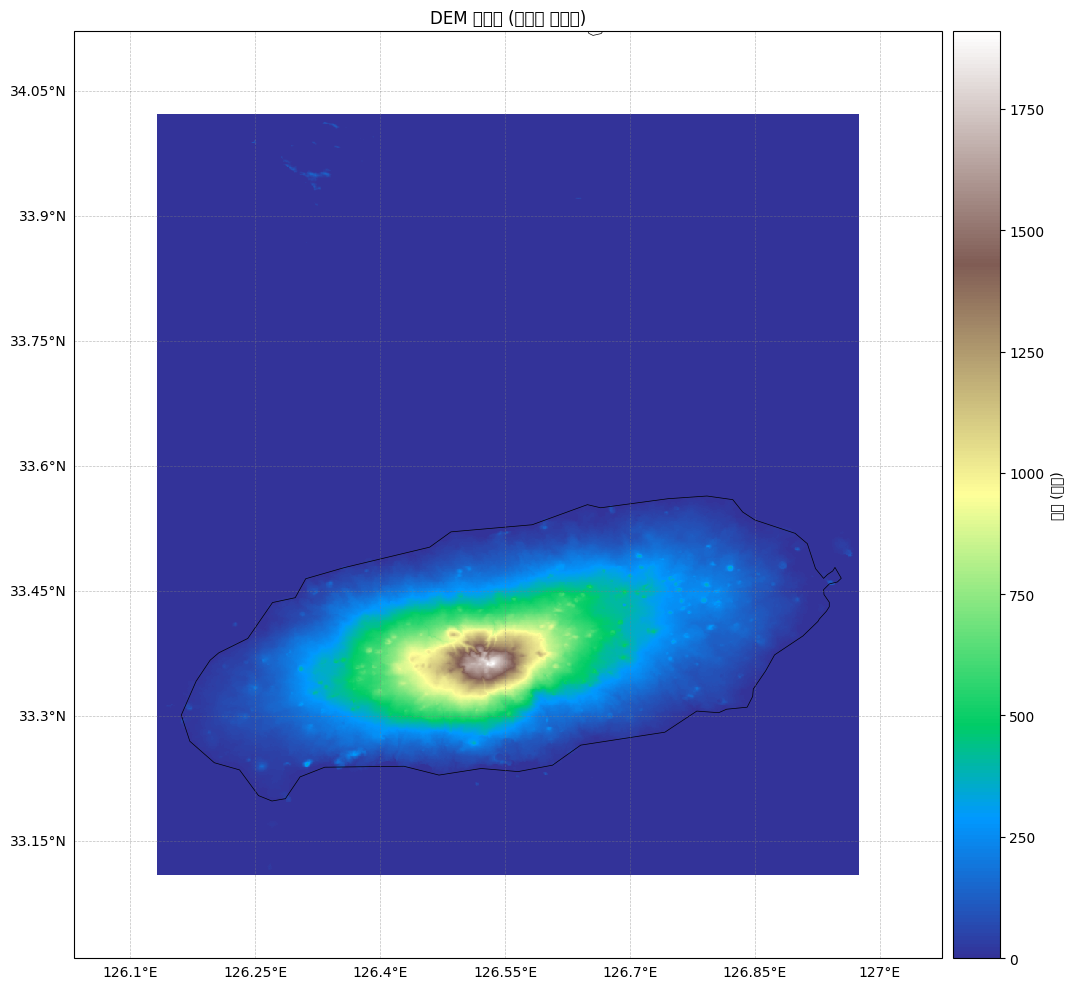

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import netCDF4 as nc

def visualize_nc_dem(nc_file, output_image=None, figsize=(12, 10), cmap='terrain', 
                    add_colorbar=True, show_coastlines=True, show_countries=True):
    """
    NetCDF DEM 파일을 시각화하는 함수
    
    Parameters:
    -----------
    nc_file : str
        입력 NetCDF 파일 경로
    output_image : str, optional
        출력 이미지 파일 경로, None이면 화면에 표시
    figsize : tuple, optional
        그림 크기
    cmap : str, optional
        컬러맵 이름
    add_colorbar : bool, optional
        컬러바 추가 여부
    show_coastlines : bool, optional
        해안선 표시 여부 (경위도 좌표계인 경우만 적용)
    show_countries : bool, optional
        국가 경계선 표시 여부 (경위도 좌표계인 경우만 적용)
    """
    # NetCDF 파일 열기
    dataset = nc.Dataset(nc_file, 'r')
    
    # 변수 이름 확인
    print(f"파일에 포함된 변수: {list(dataset.variables.keys())}")
    
    # 좌표계 변수 확인
    is_geographic = False
    if 'latitude' in dataset.variables and 'longitude' in dataset.variables:
        is_geographic = True
        lat = dataset.variables['latitude'][:]
        lon = dataset.variables['longitude'][:]
        elevation = dataset.variables['elevation'][:,:]
    elif 'y' in dataset.variables and 'x' in dataset.variables:
        y = dataset.variables['y'][:]
        x = dataset.variables['x'][:]
        elevation = dataset.variables['elevation'][:,:]
    else:
        # 다른 변수명 시도
        dim_names = list(dataset.dimensions.keys())
        if len(dim_names) >= 2:
            dim1 = dim_names[0]
            dim2 = dim_names[1]
            try:
                coord1 = dataset.variables[dim1][:]
                coord2 = dataset.variables[dim2][:]
                elevation = dataset.variables['elevation'][:,:]
                print(f"추정된 차원: {dim1}, {dim2}")
            except KeyError:
                # 고도 변수 이름 확인
                for var_name in dataset.variables:
                    if len(dataset.variables[var_name].dimensions) == 2:
                        elevation_var_name = var_name
                        elevation = dataset.variables[elevation_var_name][:,:]
                        print(f"추정된 고도 변수: {elevation_var_name}")
                        break
        else:
            raise ValueError("지원되지 않는 NetCDF 파일 형식입니다.")
    
    # 결측값 마스킹
    fill_value = getattr(dataset.variables['elevation'], '_FillValue', None)
    if fill_value is not None:
        elevation = np.ma.masked_equal(elevation, fill_value)
    
    # 시각화
    plt.figure(figsize=figsize)
    
    if is_geographic:
        # 경위도 좌표계인 경우 cartopy 사용
        ax = plt.axes(projection=ccrs.PlateCarree())
        
        # 한국 주변 경위도 범위 확대
        padding = 0.1  # 경계 주변 패딩
        min_lon, max_lon = min(lon), max(lon)
        min_lat, max_lat = min(lat), max(lat)
        
        # 컬러맵 설정
        norm = colors.Normalize(vmin=np.min(elevation), vmax=np.max(elevation))
        
        # 고도 데이터 플롯
        img = ax.pcolormesh(lon, lat, elevation, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
        
        # 추가 기능
        if show_coastlines:
            ax.coastlines(resolution='10m', color='black', linewidth=0.5)
        if show_countries:
            ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
        
        # 격자선
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        
        # 지도 범위 설정
        ax.set_extent([min_lon-padding, max_lon+padding, min_lat-padding, max_lat+padding])
        
        plt.title('DEM 시각화 (경위도 좌표계)')
    else:
        # 투영 좌표계인 경우 일반 이미지로 표시
        img = plt.imshow(elevation, cmap=cmap, origin='upper', 
                       extent=[min(x), max(x), min(y), max(y)])
        plt.title('DEM 시각화 (투영 좌표계)')
        plt.xlabel('X 좌표 (미터)')
        plt.ylabel('Y 좌표 (미터)')
    
    # 컬러바
    if add_colorbar:
        cbar = plt.colorbar(img, ax=plt.gca(), pad=0.01)
        cbar.set_label('고도 (미터)')
    
    plt.tight_layout()
    
    # 저장 또는 표시
    if output_image:
        plt.savefig(output_image, dpi=300, bbox_inches='tight')
        print(f"이미지가 저장되었습니다: {output_image}")
    else:
        plt.show()
    
    # NetCDF 파일 닫기
    dataset.close()

# 사용 예
if __name__ == "__main__":
    nc_file = r"C:\Yeonji\2025.01.Drought\DEM_elevation.nc"
    output_image = r"C:\Yeonji\2025.01.Drought\DEM_visualization.png"
    
    # 기본 시각화
    visualize_nc_dem(nc_file, output_image)
    
    # 3D 시각화도 추가로 생성
    nc_file_3d = r"C:\Yeonji\2025.01.Drought\DEM_elevation.nc"
    output_image_3d = r"C:\Yeonji\2025.01.Drought\DEM_3D_visualization.png"
    
    # 3D 시각화 함수 호출
    visualize_nc_dem_3d(nc_file_3d, output_image_3d)

In [ ]:
import numpy as np
import netCDF4 as nc
import os

def clip_nc_by_bounds(input_nc, output_nc, lat_min, lat_max, lon_min, lon_max, verbose=True):
    """
    NetCDF 파일을 특정 지리적 범위로 잘라서 저장하는 함수
    
    Parameters:
    -----------
    input_nc : str
        입력 NetCDF 파일 경로
    output_nc : str
        출력 NetCDF 파일 경로
    lat_min : float
        최소 위도
    lat_max : float
        최대 위도
    lon_min : float
        최소 경도
    lon_max : float
        최대 경도
    verbose : bool, optional
        상세 출력 여부
    """
    if verbose:
        print(f"NetCDF 파일을 다음 범위로 자르는 중: 위도 {lat_min}~{lat_max}, 경도 {lon_min}~{lon_max}")
    
    # 입력 NetCDF 파일 열기
    try:
        ds_in = nc.Dataset(input_nc, 'r')
    except Exception as e:
        print(f"오류: 입력 파일을 열 수 없습니다 - {e}")
        return False
    
    # 변수 이름 확인
    if verbose:
        print(f"입력 파일 변수: {list(ds_in.variables.keys())}")
    
    # 좌표 변수 확인
    if 'latitude' in ds_in.variables and 'longitude' in ds_in.variables:
        lat_var_name = 'latitude'
        lon_var_name = 'longitude'
    elif 'lat' in ds_in.variables and 'lon' in ds_in.variables:
        lat_var_name = 'lat'
        lon_var_name = 'lon'
    else:
        print("오류: 위도/경도 변수를 찾을 수 없습니다.")
        ds_in.close()
        return False
    
    # 좌표 데이터 가져오기
    lat = ds_in.variables[lat_var_name][:]
    lon = ds_in.variables[lon_var_name][:]
    
    # 좌표 범위 확인
    if verbose:
        print(f"원본 파일 좌표 범위: 위도 {np.min(lat)}~{np.max(lat)}, 경도 {np.min(lon)}~{np.max(lon)}")
    
    # 지정된 범위가 원본 데이터 범위를 벗어나는지 확인
    if lat_min < np.min(lat) or lat_max > np.max(lat) or lon_min < np.min(lon) or lon_max > np.max(lon):
        print("경고: 지정된 범위가 원본 데이터 범위를 벗어납니다. 가능한 범위 내에서만 자르겠습니다.")
        lat_min = max(lat_min, np.min(lat))
        lat_max = min(lat_max, np.max(lat))
        lon_min = max(lon_min, np.min(lon))
        lon_max = min(lon_max, np.max(lon))
    
    # 범위에 해당하는 인덱스 찾기
    # 주의: 위도가 내림차순으로 저장된 경우를 고려
    if lat[0] > lat[-1]:  # 위도가 내림차순인 경우
        lat_indices = np.where((lat <= lat_max) & (lat >= lat_min))[0]
    else:  # 위도가 오름차순인 경우
        lat_indices = np.where((lat >= lat_min) & (lat <= lat_max))[0]
    
    lon_indices = np.where((lon >= lon_min) & (lon <= lon_max))[0]
    
    if len(lat_indices) == 0 or len(lon_indices) == 0:
        print("오류: 지정된 범위 내에 데이터가 없습니다.")
        ds_in.close()
        return False
    
    lat_start, lat_end = lat_indices[0], lat_indices[-1]
    lon_start, lon_end = lon_indices[0], lon_indices[-1]
    
    if verbose:
        print(f"자를 인덱스 범위: 위도 {lat_start}~{lat_end}, 경도 {lon_start}~{lon_end}")
        lat_clipped = lat[lat_indices]
        lon_clipped = lon[lon_indices]
        print(f"자를 실제 좌표 범위: 위도 {np.min(lat_clipped)}~{np.max(lat_clipped)}, 경도 {np.min(lon_clipped)}~{np.max(lon_clipped)}")
    
    # 출력 NetCDF 파일 생성
    try:
        ds_out = nc.Dataset(output_nc, 'w', format='NETCDF4')
    except Exception as e:
        print(f"오류: 출력 파일을 생성할 수 없습니다 - {e}")
        ds_in.close()
        return False
    
    # 전역 속성 복사
    for attr_name in ds_in.ncattrs():
        ds_out.setncattr(attr_name, ds_in.getncattr(attr_name))
    
    # 수정된 설명 추가
    if hasattr(ds_out, 'description'):
        ds_out.description = ds_out.description + f" - Clipped to lat:{lat_min}~{lat_max}, lon:{lon_min}~{lon_max}"
    else:
        ds_out.description = f"Clipped from {os.path.basename(input_nc)} to lat:{lat_min}~{lat_max}, lon:{lon_min}~{lon_max}"
    
    # 차원 생성
    lat_dim = ds_out.createDimension(lat_var_name, len(lat_indices))
    lon_dim = ds_out.createDimension(lon_var_name, len(lon_indices))
    
    # 좌표 변수 생성 및 데이터 복사
    lat_var_out = ds_out.createVariable(lat_var_name, ds_in.variables[lat_var_name].datatype, (lat_var_name,))
    lon_var_out = ds_out.createVariable(lon_var_name, ds_in.variables[lon_var_name].datatype, (lon_var_name,))
    
    # 변수 속성 복사 - 안전하게 처리
    # 수정된 부분: 속성 복사 시 일반적인 예외 처리 추가
    for attr_name in ds_in.variables[lat_var_name].ncattrs():
        try:
            attr_value = ds_in.variables[lat_var_name].getncattr(attr_name)
            lat_var_out.setncattr(attr_name, attr_value)
        except:
            print(f"경고: '{lat_var_name}' 변수의 '{attr_name}' 속성을 복사할 수 없습니다.")
    
    for attr_name in ds_in.variables[lon_var_name].ncattrs():
        try:
            attr_value = ds_in.variables[lon_var_name].getncattr(attr_name)
            lon_var_out.setncattr(attr_name, attr_value)
        except:
            print(f"경고: '{lon_var_name}' 변수의 '{attr_name}' 속성을 복사할 수 없습니다.")
    
    # 좌표 데이터 복사
    lat_var_out[:] = lat[lat_indices]
    lon_var_out[:] = lon[lon_indices]
    
    # 기타 변수 복사
    for var_name in ds_in.variables:
        if var_name not in [lat_var_name, lon_var_name]:
            var_in = ds_in.variables[var_name]
            var_dims = var_in.dimensions
            
            # 변수의 차원이 위도/경도를 포함하는지 확인
            has_lat = lat_var_name in var_dims
            has_lon = lon_var_name in var_dims
            
            if has_lat or has_lon:
                # 새 차원 튜플 생성
                new_dims = []
                for dim in var_dims:
                    if dim == lat_var_name or dim == lon_var_name:
                        new_dims.append(dim)
                    else:
                        # 다른 차원은 그대로 복사
                        if dim not in ds_out.dimensions:
                            ds_out.createDimension(dim, len(ds_in.dimensions[dim]))
                        new_dims.append(dim)
                
                # 변수 생성
                var_out = ds_out.createVariable(var_name, var_in.datatype, tuple(new_dims), 
                                            zlib=True, complevel=4)
                
                # 변수 속성 복사 - 안전하게 처리
                for attr_name in var_in.ncattrs():
                    try:
                        attr_value = var_in.getncattr(attr_name)
                        var_out.setncattr(attr_name, attr_value)
                    except:
                        print(f"경고: '{var_name}' 변수의 '{attr_name}' 속성을 복사할 수 없습니다.")
                
                # 인덱싱을 위한 슬라이스 객체 생성
                slice_indices = []
                for i, dim in enumerate(var_dims):
                    if dim == lat_var_name:
                        slice_indices.append(slice(lat_start, lat_end + 1))
                    elif dim == lon_var_name:
                        slice_indices.append(slice(lon_start, lon_end + 1))
                    else:
                        slice_indices.append(slice(None))
                
                # 데이터 복사
                var_out[:] = var_in[tuple(slice_indices)]
                
                if verbose:
                    print(f"변수 '{var_name}' 복사 완료")
            else:
                # 위도/경도와 관련 없는 변수는 그대로 복사
                new_dims = []
                for dim in var_dims:
                    if dim not in ds_out.dimensions:
                        ds_out.createDimension(dim, len(ds_in.dimensions[dim]))
                    new_dims.append(dim)
                
                var_out = ds_out.createVariable(var_name, var_in.datatype, var_dims)
                
                # 변수 속성 복사 - 안전하게 처리
                for attr_name in var_in.ncattrs():
                    try:
                        attr_value = var_in.getncattr(attr_name)
                        var_out.setncattr(attr_name, attr_value)
                    except:
                        print(f"경고: '{var_name}' 변수의 '{attr_name}' 속성을 복사할 수 없습니다.")
                
                var_out[:] = var_in[:]
                
                if verbose:
                    print(f"변수 '{var_name}'(비공간) 복사 완료")
    
    # 파일 닫기
    ds_in.close()
    ds_out.close()
    
    if verbose:
        print(f"완료: {output_nc} 파일이 생성되었습니다.")
    
    return True

In [ ]:
# 사용 예
input_nc = r"C:\Yeonji\2025.01.Drought\DEM_elevation.nc"
output_nc = r"C:\Yeonji\2025.01.Drought\DEM_jeju.nc"

# 제주도 영역
jeju_lat_start, jeju_lat_end = 33.1, 33.6
jeju_lon_start, jeju_lon_end = 126.1, 127.1

# 파일 자르기
clip_nc_by_bounds(input_nc, output_nc, jeju_lat_start, jeju_lat_end, jeju_lon_start, jeju_lon_end)

NetCDF 파일을 다음 범위로 자르는 중: 위도 33.1~33.6, 경도 126.1~127.1
입력 파일 변수: ['latitude', 'longitude', 'elevation', 'crs']
원본 파일 좌표 범위: 위도 33.109012603759766~34.02175521850586, 경도 126.13211059570312~126.97403717041016
경고: 지정된 범위가 원본 데이터 범위를 벗어납니다. 가능한 범위 내에서만 자르겠습니다.
자를 인덱스 범위: 위도 483~1044, 경도 0~963
자를 실제 좌표 범위: 위도 33.109012603759766~33.59947967529297, 경도 126.13211059570312~126.97403717041016
경고: 'elevation' 변수의 '_FillValue' 속성을 복사할 수 없습니다.
변수 'elevation'(비공간) 복사 완료
변수 'crs'(비공간) 복사 완료
완료: C:\Yeonji\2025.01.Drought\DEM_jeju.nc 파일이 생성되었습니다.


True